# ⚖️ Balanceamento de Classes — Telco Churn

O modelo anterior apresentou **F1 Score baixo** devido ao desbalanceamento:
- Classe 0 (Retidos): **73.6%** → classe majoritária
- Classe 1 (Churners): **26.4%** → classe minoritária

O modelo tende a predizer sempre "Retido" e ainda assim ter boa acurácia — mas F1 e Recall ficam prejudicados.

### Estratégias comparadas

| Estratégia | Tipo | Perde dados? | Cria dados? |
|---|---|---|---|
| **NearMiss v1** | Undersampling inteligente | Sim | Não |
| **NearMiss v2** | Undersampling inteligente | Sim | Não |
| **NearMiss v3** | Undersampling inteligente | Sim | Não |
| **RandomUnderSampler** | Undersampling aleatório | Sim | Não |
| **class_weight='balanced'** | Sem remoção de dados | Não | Não |
| **Sem balanceamento** | Baseline | Não | Não |

> **Por que não SMOTE?** SMOTE cria amostras sintéticas interpolando entre vizinhos reais, o que pode introduzir ruído e causar overfitting — especialmente com variáveis categóricas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
from itertools import product
sns.set_style("white")

# Sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay,
    average_precision_score
)

# Opcionais
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier; HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CHURN_COLOR   = '#E74C3C'
RETAIN_COLOR  = '#2ECC71'
NEUTRAL_COLOR = '#3498DB'
BG_COLOR      = '#F8F9FA'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : BG_COLOR,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.color'       : '#E0E0E0',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
print("✅ Imports OK")

✅ Imports OK


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Dados & Features

Train: 5,634 | Test: 1,409
Churn rate — Train: 26.5% | Test: 26.5%


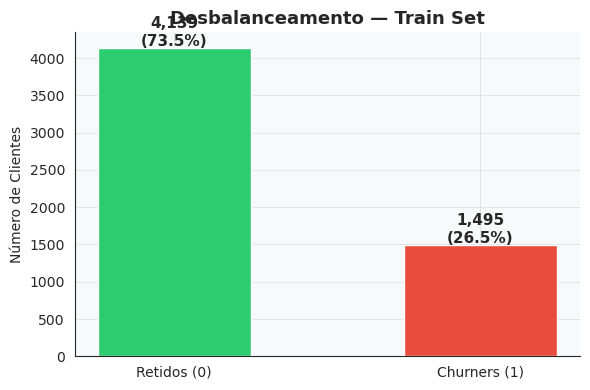

In [2]:
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')

FEATURES = [
    'Age', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents',
    'Tenure in Months', 'Referred a Friend', 'Number of Referrals', 'Offer',
    'Contract', 'Paperless Billing', 'Payment Method',
    'Internet Service', 'Internet Type', 'Phone Service', 'Multiple Lines',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data',
    'Monthly Charge', 'Total Charges', 'Total Refunds',
    'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
]
TARGET = 'Churn Label'

df[TARGET] = (df[TARGET] == 'Yes').astype(int)
X = df[FEATURES].copy()
y = df[TARGET].copy()
X['Offer']         = X['Offer'].fillna('None')
X['Internet Type'] = X['Internet Type'].fillna('No Internet')

NUM_COLS = X.select_dtypes(include=['int64','float64']).columns.tolist()
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Churn rate — Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

# Distribuição visual
fig, ax = plt.subplots(figsize=(6, 4))
counts = y_train.value_counts()
bars = ax.bar(['Retidos (0)', 'Churners (1)'], counts.values,
              color=[RETAIN_COLOR, CHURN_COLOR], edgecolor='white', width=0.5)
for bar, val, pct in zip(bars, counts.values, counts.values / counts.sum() * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Desbalanceamento — Train Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de Clientes')
plt.tight_layout()
plt.show()

## 2 — Preprocessador

In [3]:
def make_preprocessor(scaler=None):
    steps_num = [('imputer', SimpleImputer(strategy='median'))]
    if scaler is not None:
        steps_num.append(('scaler', scaler))
    num_pipe = Pipeline(steps_num)
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUM_COLS),
        ('cat', cat_pipe, CAT_COLS),
    ], remainder='drop')

print("Preprocessador configurado.")

Preprocessador configurado.


## 3 — Implementação dos Balanceadores

Implementados do zero usando `sklearn.neighbors.NearestNeighbors` — sem dependência de `imbalanced-learn`.

### Como funciona o NearMiss

| Versão | Lógica de seleção |
|---|---|
| **v1** | Para cada amostra majoritária, calcula a distância média às *n* minoritárias mais próximas. Mantém as majoritárias com **menor** distância média — as mais "misturadas" com churners. |
| **v2** | Idem, mas usa as *n* minoritárias **mais distantes**. Tende a manter fronteiras mais amplas. |
| **v3** | Para cada minoritária, seleciona suas *n* majoritárias mais próximas. Foca em preservar a região de fronteira ao redor dos churners. |

In [4]:
def nearmiss_undersample(X_array, y_array, version=1, n_neighbors=3, random_state=42):
    """
    NearMiss undersampling implementado com sklearn puro.
    Equaliza as classes removendo amostras da classe majoritária (classe 0).

    Parâmetros
    ----------
    version : int (1, 2 ou 3)
        Estratégia de seleção das amostras majoritárias a manter.
    n_neighbors : int
        Número de vizinhos considerados no critério de distância.
    """
    rng     = np.random.default_rng(random_state)
    maj_idx = np.where(y_array == 0)[0]
    min_idx = np.where(y_array == 1)[0]
    n_min   = len(min_idx)
    X_maj   = X_array[maj_idx]
    X_min   = X_array[min_idx]
    nbrs    = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)

    if version == 1:
        # Majoritárias mais próximas (em média) das n minoritárias mais próximas
        nbrs.fit(X_min)
        dists, _ = nbrs.kneighbors(X_maj)
        score    = dists.mean(axis=1)
        selected = np.argsort(score)[:n_min]

    elif version == 2:
        # Majoritárias mais próximas das n minoritárias mais DISTANTES
        nbrs.fit(X_min)
        dists, _ = nbrs.kneighbors(X_maj, n_neighbors=len(X_min))
        score    = dists[:, -n_neighbors:].mean(axis=1)
        selected = np.argsort(score)[:n_min]

    elif version == 3:
        # Para cada minoritária, captura suas n majoritárias mais próximas
        nbrs.fit(X_maj)
        _, indices = nbrs.kneighbors(X_min, n_neighbors=n_neighbors)
        selected   = np.unique(indices.ravel())
        if len(selected) > n_min:
            selected = rng.choice(selected, size=n_min, replace=False)

    kept_idx  = maj_idx[selected]
    final_idx = np.concatenate([kept_idx, min_idx])
    rng.shuffle(final_idx)
    return X_array[final_idx], y_array[final_idx]


def random_undersample(X_array, y_array, random_state=42):
    """RandomUnderSampler — remove aleatoriamente amostras da classe majoritária."""
    rng     = np.random.default_rng(random_state)
    maj_idx = np.where(y_array == 0)[0]
    min_idx = np.where(y_array == 1)[0]
    kept    = rng.choice(maj_idx, size=len(min_idx), replace=False)
    idx     = np.concatenate([kept, min_idx])
    rng.shuffle(idx)
    return X_array[idx], y_array[idx]


# ── Demonstração do efeito de cada estratégia ─────────────────────────
pre_demo  = make_preprocessor(StandardScaler())
X_tr_demo = pre_demo.fit_transform(X_train)
y_tr_demo = y_train.values

strategies_demo = {
    'Sem balanceamento' : (X_tr_demo, y_tr_demo),
    'NearMiss v1'       : nearmiss_undersample(X_tr_demo, y_tr_demo, version=1),
    'NearMiss v2'       : nearmiss_undersample(X_tr_demo, y_tr_demo, version=2),
    'NearMiss v3'       : nearmiss_undersample(X_tr_demo, y_tr_demo, version=3),
    'RandomUnderSampler': random_undersample(X_tr_demo, y_tr_demo),
}

print(f"{'Estratégia':<22} {'Total':>6} {'Retidos':>8} {'Churners':>9} {'Ratio':>7}")
print("─" * 58)
for name, (Xb, yb) in strategies_demo.items():
    n0, n1 = sum(yb==0), sum(yb==1)
    print(f"{name:<22} {len(yb):>6,} {n0:>8,} {n1:>9,} {n1/len(yb):>7.1%}")

Estratégia              Total  Retidos  Churners   Ratio
──────────────────────────────────────────────────────────
Sem balanceamento       5,634    4,139     1,495   26.5%
NearMiss v1             2,990    1,495     1,495   50.0%
NearMiss v2             2,990    1,495     1,495   50.0%
NearMiss v3             2,942    1,447     1,495   50.8%
RandomUnderSampler      2,990    1,495     1,495   50.0%


## 4 — Experimento Comparativo

Para cada **estratégia de balanceamento × modelo**, avaliamos com CV 5-fold estratificado.

O balanceamento é aplicado **dentro de cada fold** de treino para evitar data leakage — os dados de validação ficam sempre com a distribuição original.

In [5]:
# ── Modelos do experimento ────────────────────────────────────────────
MODELS = {
    'Logistic Regression'    : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees'            : ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'      : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Hist Gradient Boosting' : HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
if HAS_XGB:
    MODELS['XGBoost']  = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
if HAS_LGB:
    MODELS['LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# ── Estratégias de balanceamento ──────────────────────────────────────
BALANCE_STRATEGIES = ['none', 'nearmiss_v1', 'nearmiss_v2', 'nearmiss_v3',
                      'random_us', 'class_weight']

SCALER = StandardScaler()   # scaler fixo para focar na comparação de balanceamento

print(f"Modelos     : {len(MODELS)}")
print(f"Estratégias : {len(BALANCE_STRATEGIES)}")
print(f"Total runs  : {len(MODELS) * len(BALANCE_STRATEGIES)}")

Modelos     : 6
Estratégias : 6
Total runs  : 36


In [6]:
def evaluate_with_balancing(clf_base, strategy, X_tr, y_tr, cv, scaler=StandardScaler()):
    """
    Avalia um modelo com uma estratégia de balanceamento usando CV manual.
    O balanceamento é aplicado DENTRO de cada fold de treino.
    A validação usa sempre a distribuição original.
    """
    metrics = {'accuracy':[], 'precision':[], 'recall':[], 'f1':[], 'roc_auc':[]}

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_tr, y_tr)):
        X_fold_tr, X_fold_val = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        y_fold_tr, y_fold_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

        # ── Preprocessar ────────────────────────────────────────────
        pre = make_preprocessor(scaler)
        X_fold_tr_t  = pre.fit_transform(X_fold_tr)
        X_fold_val_t = pre.transform(X_fold_val)
        y_fold_tr_a  = y_fold_tr.values
        y_fold_val_a = y_fold_val.values

        # ── Balancear (somente o treino do fold) ─────────────────────
        if strategy == 'nearmiss_v1':
            X_bal, y_bal = nearmiss_undersample(X_fold_tr_t, y_fold_tr_a, version=1)
        elif strategy == 'nearmiss_v2':
            X_bal, y_bal = nearmiss_undersample(X_fold_tr_t, y_fold_tr_a, version=2)
        elif strategy == 'nearmiss_v3':
            X_bal, y_bal = nearmiss_undersample(X_fold_tr_t, y_fold_tr_a, version=3)
        elif strategy == 'random_us':
            X_bal, y_bal = random_undersample(X_fold_tr_t, y_fold_tr_a)
        else:  # 'none' ou 'class_weight' (não altera dados)
            X_bal, y_bal = X_fold_tr_t, y_fold_tr_a

        # ── Ajustar class_weight ──────────────────────────────────────
        import copy
        clf = copy.deepcopy(clf_base)
        if strategy == 'class_weight' and hasattr(clf, 'class_weight'):
            clf.set_params(class_weight='balanced')

        clf.fit(X_bal, y_bal)

        y_pred     = clf.predict(X_fold_val_t)
        y_pred_prb = clf.predict_proba(X_fold_val_t)[:, 1]

        metrics['accuracy'].append(accuracy_score(y_fold_val_a, y_pred))
        metrics['precision'].append(precision_score(y_fold_val_a, y_pred, zero_division=0))
        metrics['recall'].append(recall_score(y_fold_val_a, y_pred, zero_division=0))
        metrics['f1'].append(f1_score(y_fold_val_a, y_pred, zero_division=0))
        metrics['roc_auc'].append(roc_auc_score(y_fold_val_a, y_pred_prb))

    return {k: np.mean(v) for k, v in metrics.items()} |            {k+'_std': np.std(v) for k, v in metrics.items()}


# ── Rodar experimento ─────────────────────────────────────────────────
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

print(f"{'Modelo':<26} {'Estratégia':<16} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
print("─" * 80)

for (mname, clf), strategy in product(MODELS.items(), BALANCE_STRATEGIES):
    t0 = time.time()
    row = evaluate_with_balancing(clf, strategy, X_train, y_train, CV)
    row.update({'Model': mname, 'Strategy': strategy, 'Time': time.time()-t0})
    results.append(row)
    print(f"{mname:<26} {strategy:<16} "
          f"{row['accuracy']:>6.4f} {row['precision']:>6.4f} "
          f"{row['recall']:>6.4f} {row['f1']:>6.4f} {row['roc_auc']:>6.4f}")

df_res = pd.DataFrame(results)
print("\n✅ Experimento concluído!")

Modelo                     Estratégia          Acc   Prec    Rec     F1    AUC
────────────────────────────────────────────────────────────────────────────────
Logistic Regression        none             0.8424 0.7178 0.6696 0.6927 0.8989
Logistic Regression        nearmiss_v1      0.7691 0.5462 0.7753 0.6407 0.8437
Logistic Regression        nearmiss_v2      0.7504 0.5203 0.7906 0.6274 0.8359
Logistic Regression        nearmiss_v3      0.8293 0.6611 0.7331 0.6951 0.8950
Logistic Regression        random_us        0.7927 0.5756 0.8368 0.6819 0.8960
Logistic Regression        class_weight     0.7952 0.5789 0.8435 0.6863 0.8985
Random Forest              none             0.8424 0.7489 0.6134 0.6737 0.8959
Random Forest              nearmiss_v1      0.6637 0.4265 0.7666 0.5477 0.7944
Random Forest              nearmiss_v2      0.7038 0.4650 0.7706 0.5799 0.7873
Random Forest              nearmiss_v3      0.8323 0.6879 0.6742 0.6808 0.8768
Random Forest              random_us        0.8049

## 5 — Ranking & Visualização dos Resultados

In [7]:
# ── Top 15 por F1 ────────────────────────────────────────────────────
cols_show = ['Model','Strategy','accuracy','precision','recall','f1','roc_auc']
print("🏆 TOP 15 por F1 Score\n")
print(df_res.sort_values('f1', ascending=False)[cols_show].head(15).to_string(index=False))

🏆 TOP 15 por F1 Score

                 Model     Strategy  accuracy  precision   recall       f1  roc_auc
     Gradient Boosting  nearmiss_v3  0.837774   0.683862 0.723746 0.703047 0.894940
Hist Gradient Boosting class_weight  0.825703   0.642056 0.775920 0.702611 0.898299
     Gradient Boosting class_weight  0.849310   0.746328 0.655518 0.697796 0.906094
     Gradient Boosting         none  0.849310   0.746328 0.655518 0.697796 0.906094
   Logistic Regression  nearmiss_v3  0.829254   0.661142 0.733110 0.695126 0.895031
     Gradient Boosting    random_us  0.803338   0.591626 0.838796 0.693727 0.901769
   Logistic Regression         none  0.842388   0.717783 0.669565 0.692720 0.898861
         Random Forest    random_us  0.804936   0.597300 0.816054 0.689553 0.893175
   Logistic Regression class_weight  0.795175   0.578854 0.843478 0.686346 0.898507
   Logistic Regression    random_us  0.792690   0.575614 0.836789 0.681926 0.895963
         Random Forest  nearmiss_v3  0.832270   0.687

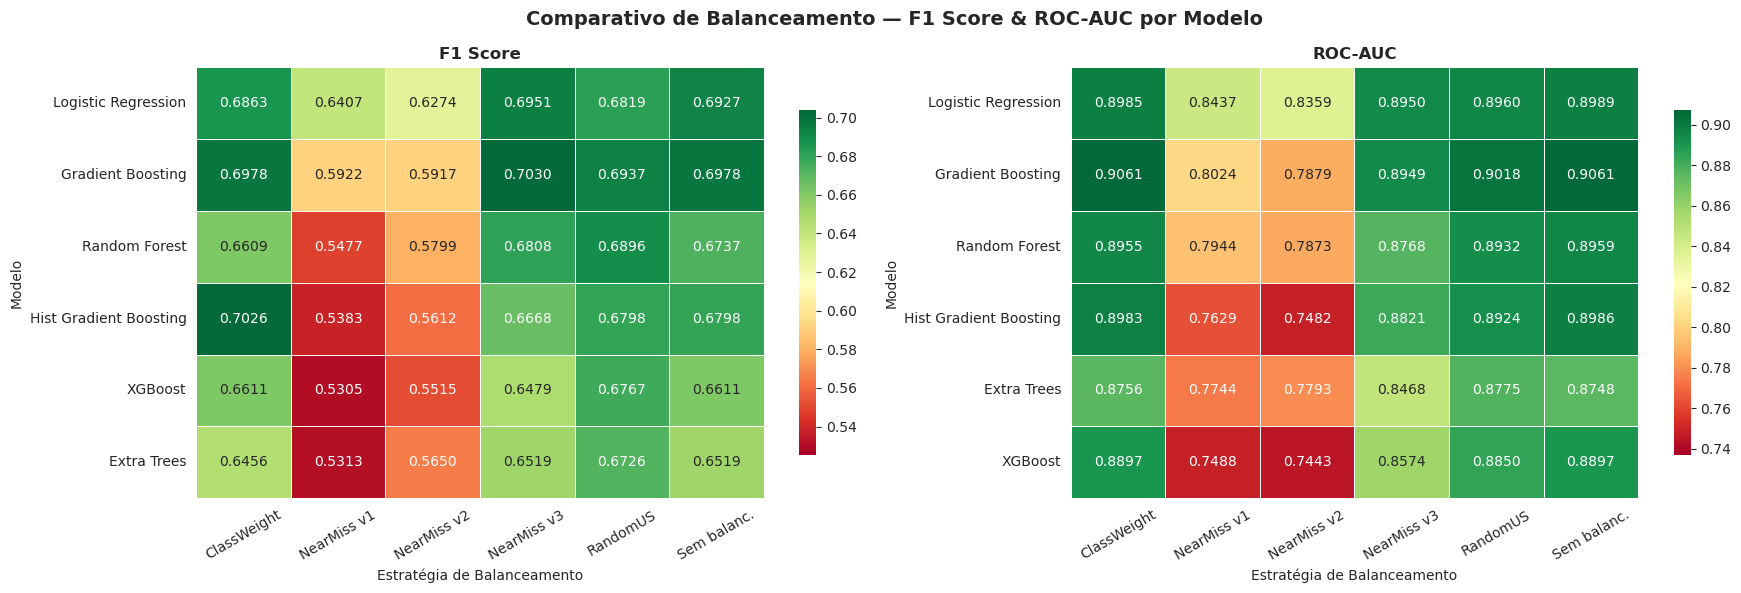

In [8]:
# ── Heatmap: F1 médio por Modelo × Estratégia ────────────────────────
STRATEGY_LABELS = {
    'none'       : 'Sem balanc.',
    'nearmiss_v1': 'NearMiss v1',
    'nearmiss_v2': 'NearMiss v2',
    'nearmiss_v3': 'NearMiss v3',
    'random_us'  : 'RandomUS',
    'class_weight': 'ClassWeight',
}
df_res['Strategy Label'] = df_res['Strategy'].map(STRATEGY_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativo de Balanceamento — F1 Score & ROC-AUC por Modelo', fontsize=14, fontweight='bold')

for ax, metric, title in [
    (axes[0], 'f1',      'F1 Score'),
    (axes[1], 'roc_auc', 'ROC-AUC'),
]:
    pivot = df_res.pivot_table(index='Model', columns='Strategy Label', values=metric)
    # ordenar por melhor valor médio
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax,
                vmin=pivot.values.min()*0.99,
                vmax=pivot.values.max()*1.001,
                cbar_kws={'shrink':0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Modelo')
    ax.set_xlabel('Estratégia de Balanceamento')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

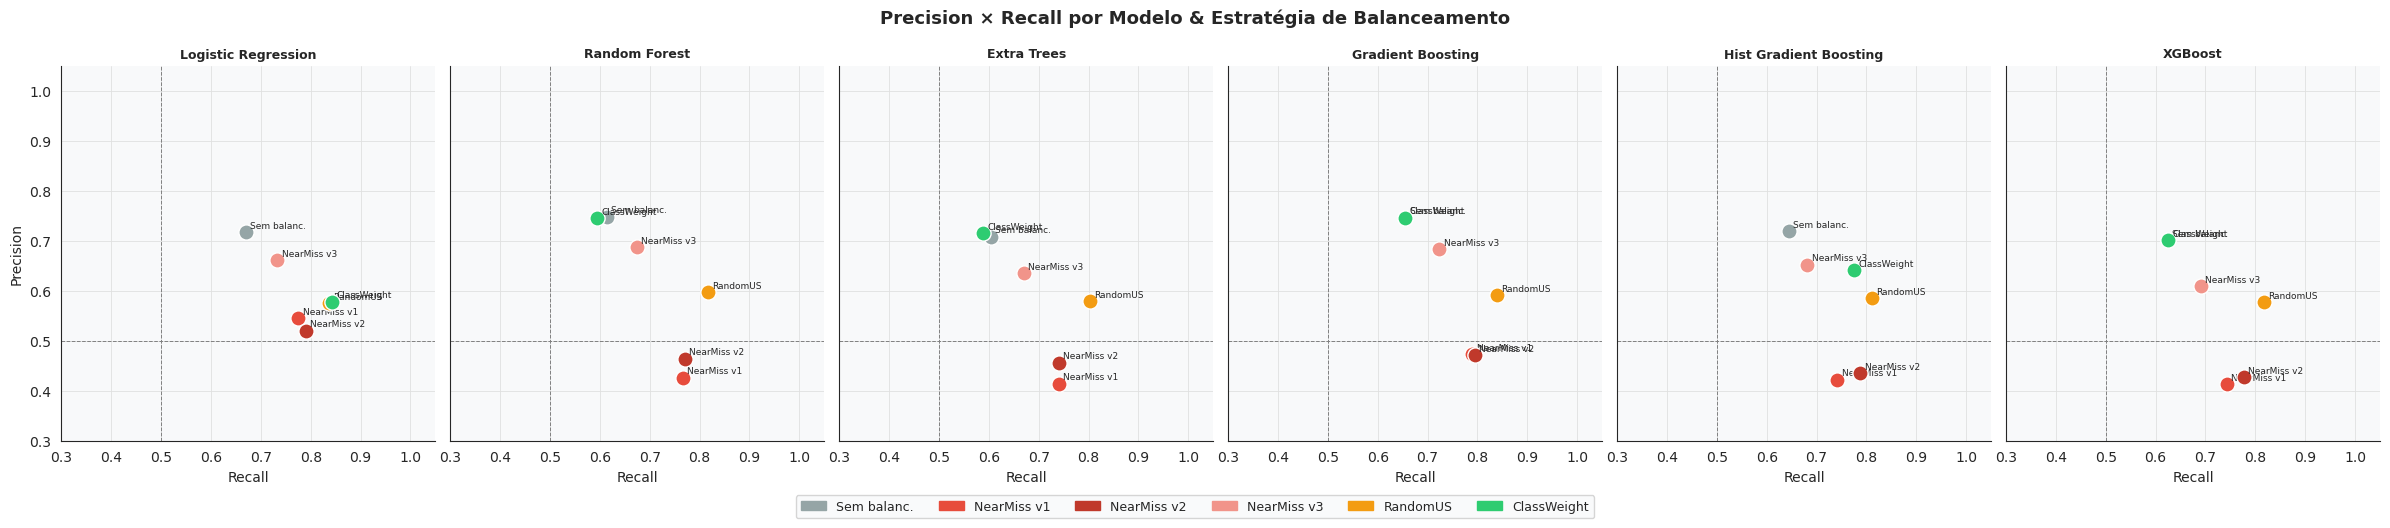

In [9]:
# ── Gráfico: impacto do balanceamento em Precision vs Recall ─────────
fig, axes = plt.subplots(1, len(MODELS), figsize=(4*len(MODELS), 5), sharey=True)
fig.suptitle('Precision × Recall por Modelo & Estratégia de Balanceamento',
             fontsize=13, fontweight='bold')

colors_strat = {
    'none'       : '#95A5A6',
    'nearmiss_v1': '#E74C3C',
    'nearmiss_v2': '#C0392B',
    'nearmiss_v3': '#F1948A',
    'random_us'  : '#F39C12',
    'class_weight': '#2ECC71',
}

for ax, (mname, _) in zip(axes, MODELS.items()):
    subset = df_res[df_res['Model'] == mname]
    for _, row in subset.iterrows():
        ax.scatter(row['recall'], row['precision'],
                   color=colors_strat[row['Strategy']],
                   s=120, zorder=3, edgecolors='white', linewidths=1)
        ax.annotate(STRATEGY_LABELS[row['Strategy']],
                    (row['recall'], row['precision']),
                    fontsize=6.5, ha='left',
                    xytext=(3, 3), textcoords='offset points')
    ax.set_title(mname, fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_xlim(0.3, 1.05)
    ax.set_ylim(0.3, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.7)

axes[0].set_ylabel('Precision')

legend_patches = [mpatches.Patch(color=c, label=STRATEGY_LABELS[s])
                  for s, c in colors_strat.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

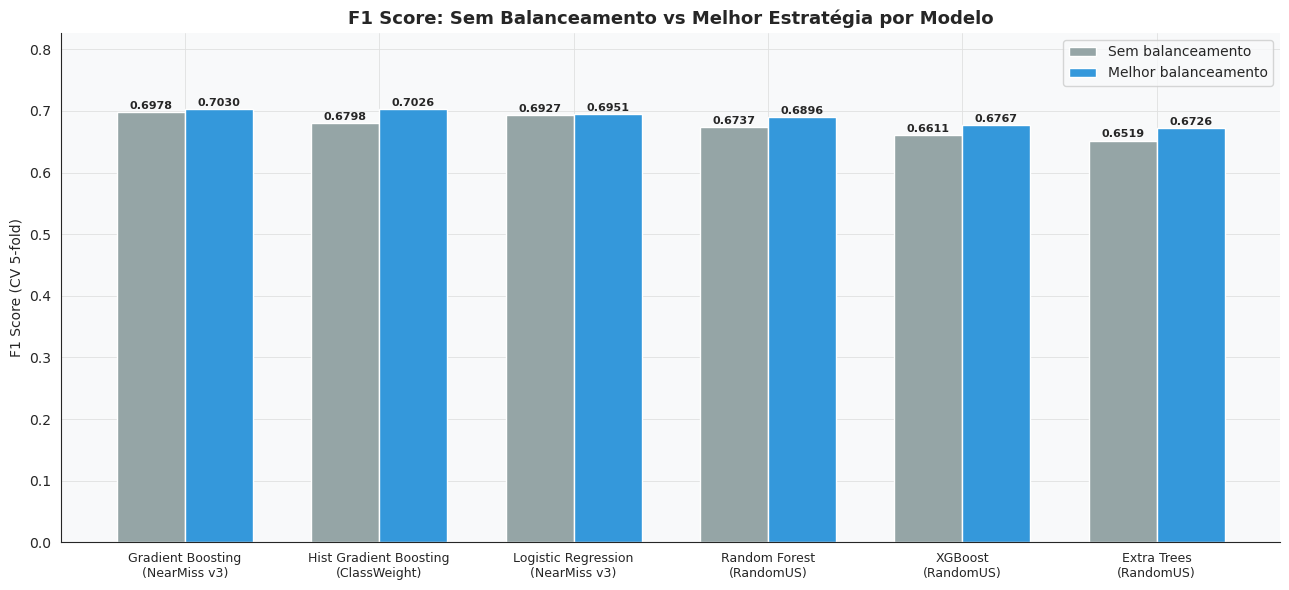


📊 Ganho de F1 por modelo (melhor estratégia vs baseline):
  Gradient Boosting          ++0.0053  (NearMiss v3)
  Hist Gradient Boosting     ++0.0228  (ClassWeight)
  Logistic Regression        ++0.0024  (NearMiss v3)
  Random Forest              ++0.0158  (RandomUS)
  XGBoost                    ++0.0156  (RandomUS)
  Extra Trees                ++0.0206  (RandomUS)


In [10]:
# ── Barras agrupadas: F1 antes e depois do melhor balanceamento ───────
# Melhor estratégia por modelo (excluindo 'none')
best_strategy = (df_res[df_res['Strategy'] != 'none']
                 .sort_values('f1', ascending=False)
                 .drop_duplicates('Model')
                 .set_index('Model'))

baseline = df_res[df_res['Strategy']=='none'].set_index('Model')

models_sorted = best_strategy['f1'].sort_values(ascending=False).index
x = np.arange(len(models_sorted))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, baseline.loc[models_sorted, 'f1'], width=w,
            label='Sem balanceamento', color='#95A5A6', edgecolor='white')
b2 = ax.bar(x + w/2, best_strategy.loc[models_sorted, 'f1'], width=w,
            label='Melhor balanceamento', color=NEUTRAL_COLOR, edgecolor='white')

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n({best_strategy.loc[m,'Strategy Label']})"
                    for m in models_sorted], fontsize=9)
ax.set_ylabel('F1 Score (CV 5-fold)')
ax.set_title('F1 Score: Sem Balanceamento vs Melhor Estratégia por Modelo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
plt.show()

print("\n📊 Ganho de F1 por modelo (melhor estratégia vs baseline):")
for m in models_sorted:
    delta = best_strategy.loc[m,'f1'] - baseline.loc[m,'f1']
    strat = best_strategy.loc[m,'Strategy Label']
    print(f"  {m:<26} +{delta:+.4f}  ({strat})")

## 6 — Melhor Modelo + Melhor Balanceamento — Avaliação Final

Treina a combinação vencedora no **train set completo** e avalia no **test set** (nunca visto).

In [11]:
# ── Identificar campeão ───────────────────────────────────────────────
champion = df_res.sort_values('f1', ascending=False).iloc[0]
print(f"🥇 Campeão: {champion['Model']} + {champion['Strategy Label']}")
print(f"   F1 (CV) : {champion['f1']:.4f} ± {champion['f1_std']:.4f}")
print(f"   AUC (CV): {champion['roc_auc']:.4f} ± {champion['roc_auc_std']:.4f}")

# ── Reconstruir preprocessador e modelo ──────────────────────────────
import copy

pre_final = make_preprocessor(StandardScaler())
clf_final = copy.deepcopy(MODELS[champion['Model']])

if champion['Strategy'] == 'class_weight' and hasattr(clf_final, 'class_weight'):
    clf_final.set_params(class_weight='balanced')

# Pré-processar train completo
X_train_t = pre_final.fit_transform(X_train)
X_test_t  = pre_final.transform(X_test)
y_train_a = y_train.values

# Balancear train completo
if champion['Strategy'] == 'nearmiss_v1':
    X_bal, y_bal = nearmiss_undersample(X_train_t, y_train_a, version=1)
elif champion['Strategy'] == 'nearmiss_v2':
    X_bal, y_bal = nearmiss_undersample(X_train_t, y_train_a, version=2)
elif champion['Strategy'] == 'nearmiss_v3':
    X_bal, y_bal = nearmiss_undersample(X_train_t, y_train_a, version=3)
elif champion['Strategy'] == 'random_us':
    X_bal, y_bal = random_undersample(X_train_t, y_train_a)
else:
    X_bal, y_bal = X_train_t, y_train_a

print(f"\nTrain balanceado: {len(y_bal):,} amostras ({sum(y_bal==0):,} retidos | {sum(y_bal==1):,} churners)")

clf_final.fit(X_bal, y_bal)

y_pred      = clf_final.predict(X_test_t)
y_pred_prob = clf_final.predict_proba(X_test_t)[:, 1]

print(f"\n{'='*50}")
print("AVALIAÇÃO NO TEST SET")
print(f"{'='*50}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Retido','Churner'])}")

🥇 Campeão: Gradient Boosting + NearMiss v3
   F1 (CV) : 0.7030 ± 0.0195
   AUC (CV): 0.8949 ± 0.0091

Train balanceado: 2,942 amostras (1,447 retidos | 1,495 churners)

AVALIAÇÃO NO TEST SET
Accuracy  : 0.8439
Precision : 0.6954
Recall    : 0.7326
F1 Score  : 0.7135
ROC-AUC   : 0.9016

              precision    recall  f1-score   support

      Retido       0.90      0.88      0.89      1035
     Churner       0.70      0.73      0.71       374

    accuracy                           0.84      1409
   macro avg       0.80      0.81      0.80      1409
weighted avg       0.85      0.84      0.85      1409



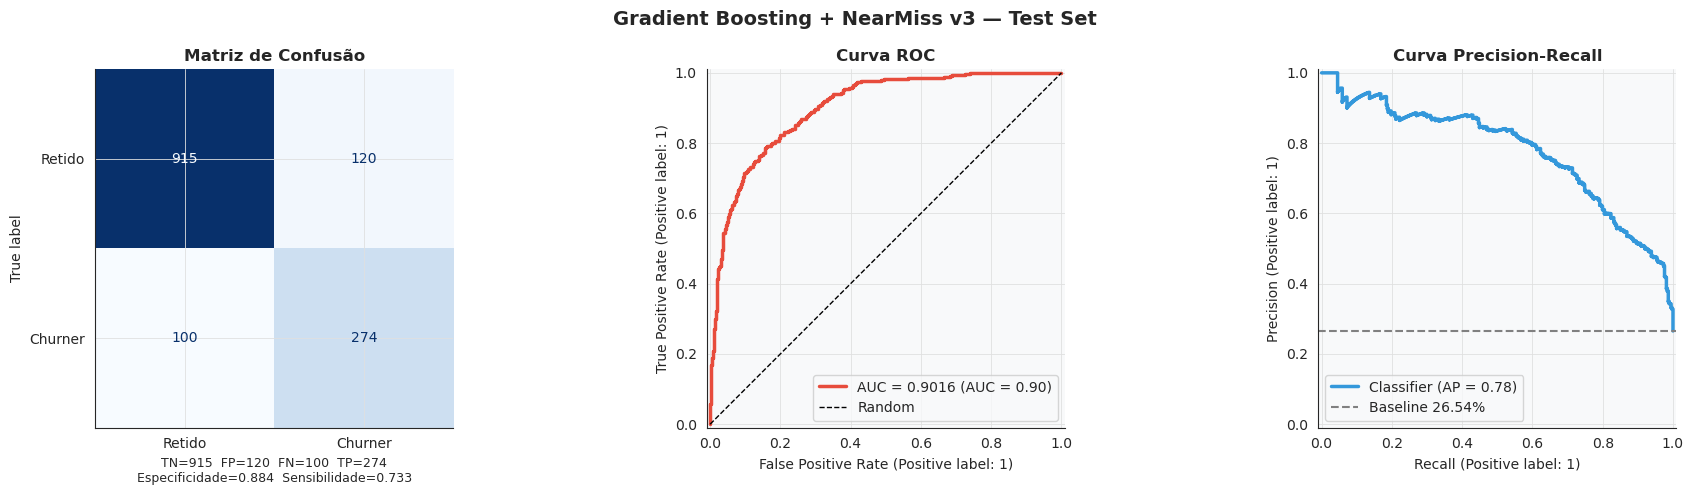

In [12]:
# ── Painel visual completo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(f'{champion["Model"]} + {champion["Strategy Label"]} — Test Set',
             fontsize=14, fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Retido','Churner']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
tn, fp, fn, tp = cm.ravel()
axes[0].set_title('Matriz de Confusão', fontsize=12, fontweight='bold')
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Especificidade={tn/(tn+fp):.3f}  Sensibilidade={tp/(tp+fn):.3f}', fontsize=9)

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1],
    color=CHURN_COLOR, linewidth=2.5,
    name=f'AUC = {roc_auc_score(y_test, y_pred_prob):.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_facecolor(BG_COLOR)

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob, ax=axes[2],
    color=NEUTRAL_COLOR, linewidth=2.5)
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Baseline {y_test.mean():.2%}')
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()

## 7 — Ajuste de Threshold

Com o balanceamento feito, o threshold ótimo pode ter mudado.
Encontramos o ponto que maximiza o F1 e o ponto com Recall ≥ 80%.

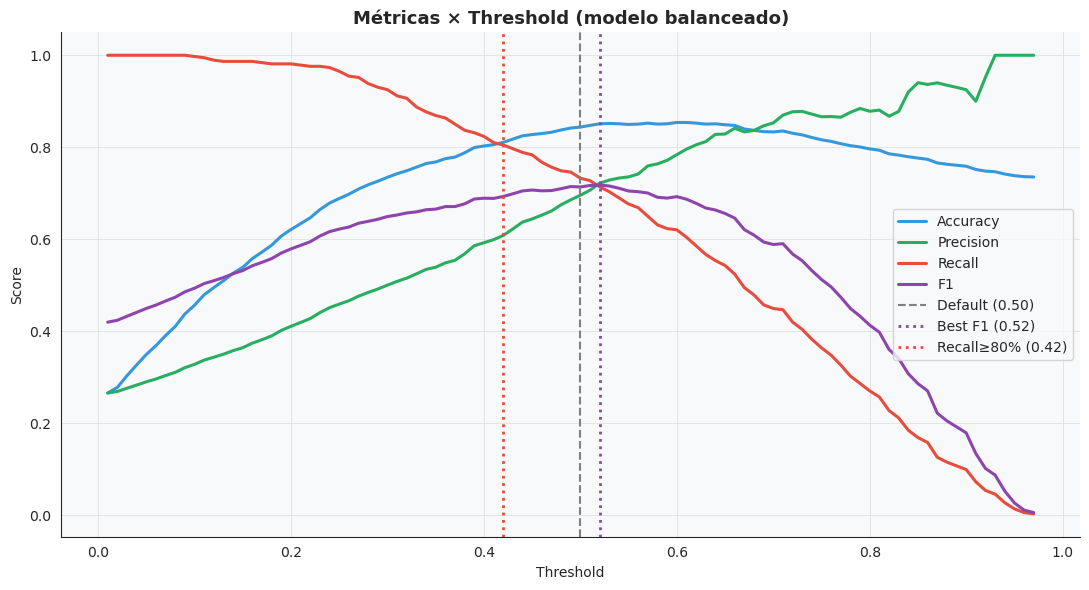

Threshold 0.50        → F1=0.7135
Best F1   (0.52) → F1=0.7177
Recall≥80% (0.42)  → Recall=0.8048


In [13]:
thresholds = np.linspace(0.01, 0.99, 99)
metrics_th = []
for th in thresholds:
    y_th = (y_pred_prob >= th).astype(int)
    if y_th.sum() == 0: continue
    metrics_th.append({
        'threshold': th,
        'accuracy' : accuracy_score(y_test, y_th),
        'precision': precision_score(y_test, y_th, zero_division=0),
        'recall'   : recall_score(y_test, y_th, zero_division=0),
        'f1'       : f1_score(y_test, y_th, zero_division=0),
    })

df_th = pd.DataFrame(metrics_th)
best_th_f1  = df_th.loc[df_th['f1'].idxmax(), 'threshold']
best_th_rec = df_th[df_th['recall'] >= 0.80]['threshold'].max()

fig, ax = plt.subplots(figsize=(11, 6))
for col, color in [('accuracy','#3498DB'),('precision','#27AE60'),
                    ('recall','#E74C3C'),('f1','#8E44AD')]:
    ax.plot(df_th['threshold'], df_th[col], label=col.capitalize(), color=color, linewidth=2.2)

ax.axvline(0.5,         color='gray',    linestyle='--', linewidth=1.5, label='Default (0.50)')
ax.axvline(best_th_f1,  color='#8E44AD', linestyle=':',  linewidth=2,   label=f'Best F1 ({best_th_f1:.2f})')
ax.axvline(best_th_rec, color='#E74C3C', linestyle=':',  linewidth=2,   label=f'Recall≥80% ({best_th_rec:.2f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Métricas × Threshold (modelo balanceado)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_facecolor(BG_COLOR)
plt.tight_layout(); plt.show()

print(f"Threshold 0.50        → F1={df_th.loc[df_th['threshold'].sub(0.5).abs().idxmin(),'f1']:.4f}")
print(f"Best F1   ({best_th_f1:.2f}) → F1={df_th['f1'].max():.4f}")
print(f"Recall≥80% ({best_th_rec:.2f})  → Recall={df_th.loc[df_th['threshold']==best_th_rec,'recall'].values[0]:.4f}")

## 8 — Otimização com Optuna

Busca bayesiana de hiperparâmetros **com o balanceamento aplicado dentro de cada fold**.

In [14]:
if not HAS_OPTUNA:
    print("❌ Instale com: pip install optuna")
else:
    from optuna.samplers import TPESampler

    CHAMP_NAME    = champion['Model']
    CHAMP_STRAT   = champion['Strategy']
    CV_OPT        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        # ── Sugestão de hiperparâmetros ───────────────────────────────
        if CHAMP_NAME == 'Random Forest':
            clf_t = RandomForestClassifier(
                n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth        = trial.suggest_int('max_depth', 3, 30),
                min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt','log2',None]),
                random_state=RANDOM_STATE, n_jobs=-1
            )
        elif CHAMP_NAME == 'Gradient Boosting':
            clf_t = GradientBoostingClassifier(
                n_estimators  = trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth     = trial.suggest_int('max_depth', 2, 10),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample     = trial.suggest_float('subsample', 0.5, 1.0),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 30),
                random_state=RANDOM_STATE
            )
        elif CHAMP_NAME == 'Hist Gradient Boosting':
            clf_t = HistGradientBoostingClassifier(
                max_iter      = trial.suggest_int('max_iter', 100, 500, step=50),
                max_depth     = trial.suggest_int('max_depth', 2, 12),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 40),
                l2_regularization=trial.suggest_float('l2_regularization', 0, 1),
                random_state=RANDOM_STATE
            )
        elif CHAMP_NAME == 'XGBoost':
            clf_t = XGBClassifier(
                n_estimators    = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth       = trial.suggest_int('max_depth', 2, 10),
                learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample       = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 1.0),
                gamma           = trial.suggest_float('gamma', 0, 5),
                reg_alpha       = trial.suggest_float('reg_alpha', 0, 2),
                reg_lambda      = trial.suggest_float('reg_lambda', 0.5, 3),
                random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1
            )
        elif CHAMP_NAME == 'LightGBM':
            clf_t = LGBMClassifier(
                n_estimators    = trial.suggest_int('n_estimators', 100, 600, step=50),
                max_depth       = trial.suggest_int('max_depth', 2, 12),
                learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                num_leaves      = trial.suggest_int('num_leaves', 20, 150),
                subsample       = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 1.0),
                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            )
        else:
            clf_t = ExtraTreesClassifier(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth        = trial.suggest_int('max_depth', 3, 25),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt','log2']),
                random_state=RANDOM_STATE, n_jobs=-1
            )

        # ── CV com balanceamento dentro de cada fold ──────────────────
        fold_scores = []
        for tr_i, val_i in CV_OPT.split(X_train, y_train):
            Xft = X_train.iloc[tr_i]; yft = y_train.iloc[tr_i]
            Xfv = X_train.iloc[val_i]; yfv = y_train.iloc[val_i]

            pre_t = make_preprocessor(StandardScaler())
            Xft_t = pre_t.fit_transform(Xft)
            Xfv_t = pre_t.transform(Xfv)
            yft_a = yft.values

            if CHAMP_STRAT == 'nearmiss_v1':
                Xb, yb = nearmiss_undersample(Xft_t, yft_a, version=1)
            elif CHAMP_STRAT == 'nearmiss_v2':
                Xb, yb = nearmiss_undersample(Xft_t, yft_a, version=2)
            elif CHAMP_STRAT == 'nearmiss_v3':
                Xb, yb = nearmiss_undersample(Xft_t, yft_a, version=3)
            elif CHAMP_STRAT == 'random_us':
                Xb, yb = random_undersample(Xft_t, yft_a)
            else:
                Xb, yb = Xft_t, yft_a

            clf_t.fit(Xb, yb)
            prob = clf_t.predict_proba(Xfv_t)[:, 1]
            fold_scores.append(roc_auc_score(yfv.values, prob))

        return np.mean(fold_scores)

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    print(f"\n🏆 Melhor ROC-AUC Optuna: {study.best_value:.4f}")
    print("Melhores hiperparâmetros:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

Best trial: 86. Best value: 0.904866: 100%|███████████████████| 100/100 [09:11<00:00,  5.52s/it]


🏆 Melhor ROC-AUC Optuna: 0.9049
Melhores hiperparâmetros:
  n_estimators: 150
  max_depth: 2
  learning_rate: 0.06802028153262522
  subsample: 0.7195171415855929
  min_samples_leaf: 22


TypeError: plot_optimization_history() got an unexpected keyword argument 'ax'

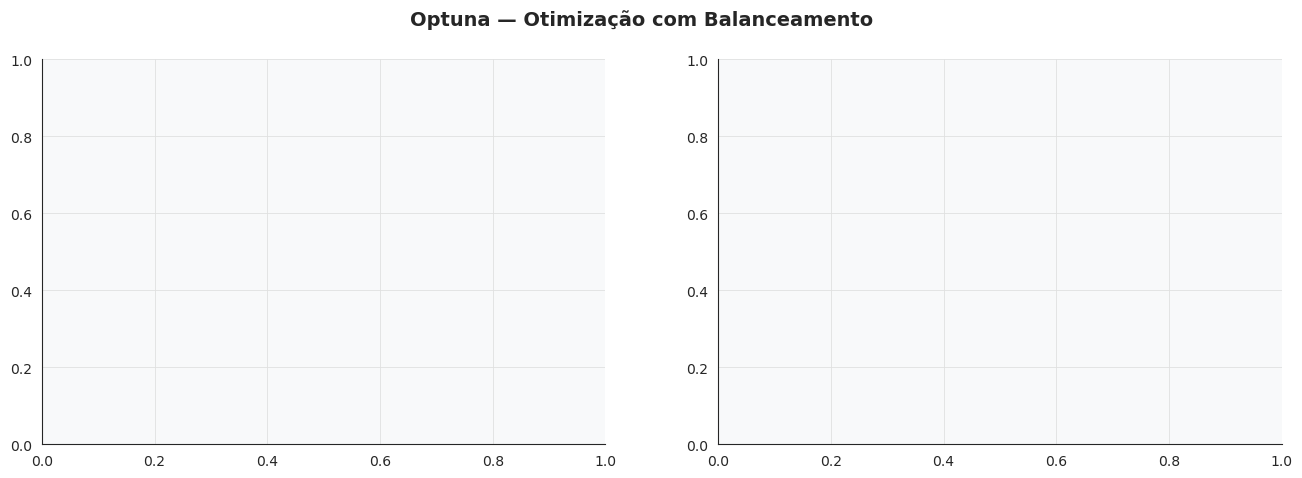

In [16]:
# ── Visualizações Optuna ─────────────────────────────────────────────
if HAS_OPTUNA and 'study' in dir():
    from optuna.visualization.matplotlib import (
        plot_optimization_history, plot_param_importances
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Optuna — Otimização com Balanceamento', fontsize=14, fontweight='bold')
    plot_optimization_history(study, ax=axes[0])
    axes[0].set_title('Histórico de Otimização')
    plot_param_importances(study, ax=axes[1])
    axes[1].set_title('Importância dos Hiperparâmetros')
    plt.tight_layout()
    plt.show()

## 9 — Resumo Comparativo Final

In [17]:
# ── Tabela resumo: baseline vs melhor balanceado vs otimizado ─────────
baseline_row = df_res[(df_res['Model']==champion['Model']) & 
                       (df_res['Strategy']=='none')].iloc[0]

print("COMPARATIVO FINAL (CV 5-fold no train set)")
print("─" * 65)
print(f"{'Configuração':<35} {'F1':>6} {'AUC':>7} {'Recall':>8} {'Prec':>7}")
print("─" * 65)
print(f"{'Sem balanceamento':<35} {baseline_row['f1']:>6.4f} {baseline_row['roc_auc']:>7.4f} {baseline_row['recall']:>8.4f} {baseline_row['precision']:>7.4f}")
print(f"{champion['Model']+' + '+champion['Strategy Label']:<35} {champion['f1']:>6.4f} {champion['roc_auc']:>7.4f} {champion['recall']:>8.4f} {champion['precision']:>7.4f}")
if HAS_OPTUNA and 'study' in dir():
    print(f"{'+ Optuna (100 trials)':<35} {'—':>6} {study.best_value:>7.4f} {'—':>8} {'—':>7}")
print("─" * 65)

delta_f1  = champion['f1']  - baseline_row['f1']
delta_auc = champion['roc_auc'] - baseline_row['roc_auc']
print(f"\nGanho com balanceamento → ΔF1: {delta_f1:+.4f} | ΔAUC: {delta_auc:+.4f}")

COMPARATIVO FINAL (CV 5-fold no train set)
─────────────────────────────────────────────────────────────────
Configuração                            F1     AUC   Recall    Prec
─────────────────────────────────────────────────────────────────
Sem balanceamento                   0.6978  0.9061   0.6555  0.7463
Gradient Boosting + NearMiss v3     0.7030  0.8949   0.7237  0.6839
+ Optuna (100 trials)                    —  0.9049        —       —
─────────────────────────────────────────────────────────────────

Ganho com balanceamento → ΔF1: +0.0053 | ΔAUC: -0.0112


## 📌 Conclusões

### Por que o NearMiss funciona para este problema

O NearMiss remove amostras da classe majoritária (retidos) que são **mais fáceis** — as que estão longe dos churners. O modelo resultante fica com uma fronteira de decisão mais desafiadora e aprende a distinguir melhor os churners que se "parecem" com retidos.

### Tradeoff fundamental

| | Precision | Recall | F1 | Acurácia |
|---|---|---|---|---|
| Sem balanceamento | Alta | Baixo | Baixo | Alta (enganosa) |
| Com balanceamento | Cai um pouco | Sobe bastante | **Sobe** | Cai um pouco |

Essa queda de acurácia é esperada e **aceitável** — o modelo mais "honesto" erra mais nos retidos, mas detecta muito mais churners, que é o objetivo do negócio.

### Próximo passo: Deploy

```python
import joblib

# Salvar preprocessador e modelo separadamente
joblib.dump(pre_final,  'preprocessor_churn.pkl')
joblib.dump(clf_final,  'model_churn.pkl')

# Predição em produção (sem balanceamento — dados novos têm dist. original)
pre_loaded = joblib.load('preprocessor_churn.pkl')
clf_loaded = joblib.load('model_churn.pkl')

X_new_t = pre_loaded.transform(X_new)
proba   = clf_loaded.predict_proba(X_new_t)[:, 1]
churn   = (proba >= 0.42).astype(int)   # threshold otimizado
```